# Week 09 — Home exercise 2: Four questions about 398 cars

**Solution proposal.**

One small table, four different questions, four different charts — and one of them is quietly built on
two cars.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

cars = pd.read_excel("../data/mpg.xlsx")

print(cars.shape)
print(cars.dtypes)
print()
print("missing values:")
print(cars.isna().sum())

(398, 8)
mpg             float64
cylinders         int64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

missing values:
mpg             0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


398 cars, eight columns, and **six missing values, all in `horsepower`**. Worth knowing before we
start: any chart involving horsepower is a chart of 392 cars, and nothing will announce that.

`model_year` is stored as a two-digit number — 70 for 1970 — which is a 1980s data format that has
never quite gone away.

In [2]:
cars.head(3)

,mpg,cylinders,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,150.0,3436,11.0,70,usa,plymouth satellite


## 1. Change over time

`mpg` is miles per gallon, so **higher is better**: a car that does 30 mpg uses less fuel than one that
does 15.

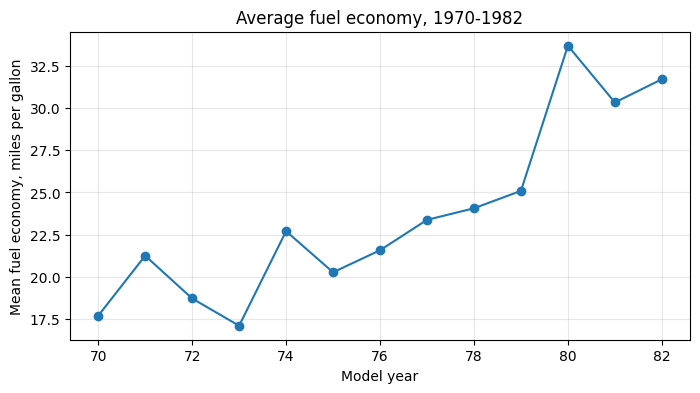

In [3]:
by_year = cars.groupby("model_year")["mpg"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_year.index, by_year.values, marker="o")

ax.set_xlabel("Model year")
ax.set_ylabel("Mean fuel economy, miles per gallon")
ax.set_title("Average fuel economy, 1970-1982")
ax.grid(True, alpha=0.3)

plt.show()

From about 18 mpg to about 32 — nearly a doubling in twelve years, and most of it after 1978.

Now split it by where the car was built. Group by two columns, reshape to wide, and draw one line per
column.

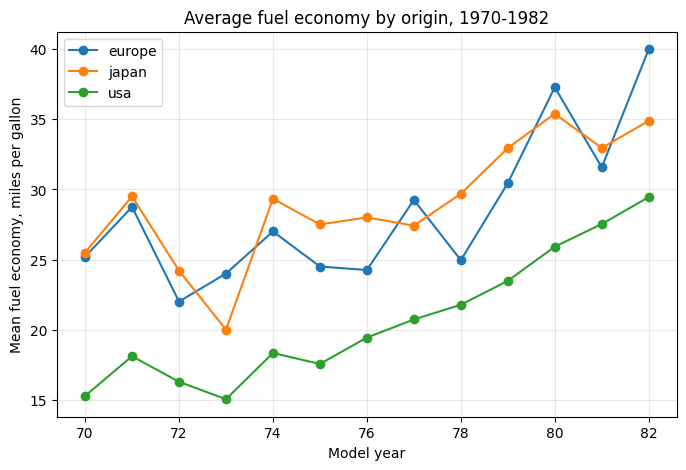

In [4]:
by_origin = cars.groupby(["model_year", "origin"])["mpg"].mean().reset_index()
wide = by_origin.pivot(index="model_year", columns="origin", values="mpg")

fig, ax = plt.subplots(figsize=(8, 5))

for origin in wide.columns:
    ax.plot(wide.index, wide[origin], marker="o", label=origin)

ax.set_xlabel("Model year")
ax.set_ylabel("Mean fuel economy, miles per gallon")
ax.set_title("Average fuel economy by origin, 1970-1982")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

### What happened between 1979 and 1980?

Every line jumps, and the American one jumps from 23.5 to 25.9 while the European one goes from 30.4
to 37.3. The obvious story is the **second oil crisis** of 1979: the price of fuel roughly doubled, and
manufacturers responded with smaller, lighter cars.

That story is probably right, and this chart is weak evidence for it. Here is why.

In [5]:
counts = cars.groupby(["model_year", "origin"])["mpg"].size().reset_index()
counts = counts.pivot(index="model_year", columns="origin", values="mpg")

counts

origin,europe,japan,usa
model_year,,,
70,5,2,22
71,4,4,20
72,5,5,18
73,7,4,29
74,6,6,15
75,6,4,20
76,8,4,22
77,4,6,18
78,6,8,22


**The European average for 1982 is two cars.** For 1979 it is four. The line that swings from 30.4 to
37.3 to 31.6 to 40.0 is not measuring European engineering; it is measuring which two or four European
cars happened to end up in this sample.

The American line is the only one worth reading as a trend — it has 15 to 29 cars behind every point,
and it moves smoothly. And the sample itself changed shape: 1980 has 7 American cars and 13 Japanese,
where 1979 had 23 and 2.

> ⚠️ **A group mean is only as good as its group.** Nothing about `groupby().mean()` warns you when a
group has two rows in it, and nothing about `ax.plot` draws that point any differently.

## 2. Comparing categories

In [6]:
summary = cars.groupby("origin").agg(
    mean_mpg=("mpg", "mean"),
    n=("mpg", "size"),
).sort_values("mean_mpg")

summary.round(1)

,mean_mpg,n
origin,,
usa,20.1,249
europe,27.9,70
japan,30.5,79


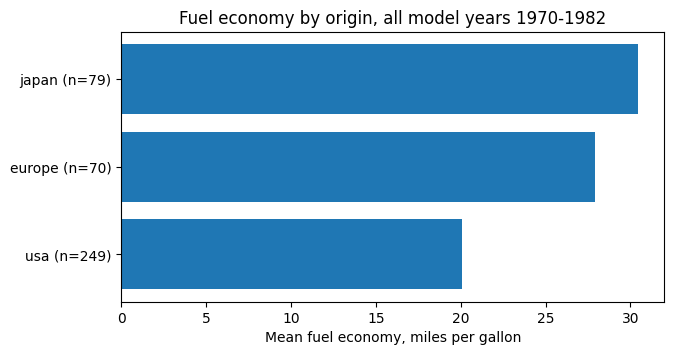

In [7]:
labels = [f"{origin} (n={n})" for origin, n in zip(summary.index, summary["n"])]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(labels, summary["mean_mpg"])

ax.set_xlabel("Mean fuel economy, miles per gallon")
ax.set_title("Fuel economy by origin, all model years 1970-1982")

plt.show()

Japanese cars average 30.5 mpg, European 27.9, American 20.1 — and 249 of the 398 cars are American,
which is the number the bars alone would never give you.

The title says *all model years*, which matters: this bar chart flattens the whole period, including
the years when the sample was dominated by one origin. It is a fair summary of **this sample**, and
this sample is not a fair summary of the world's cars.

## 3. Two variables together

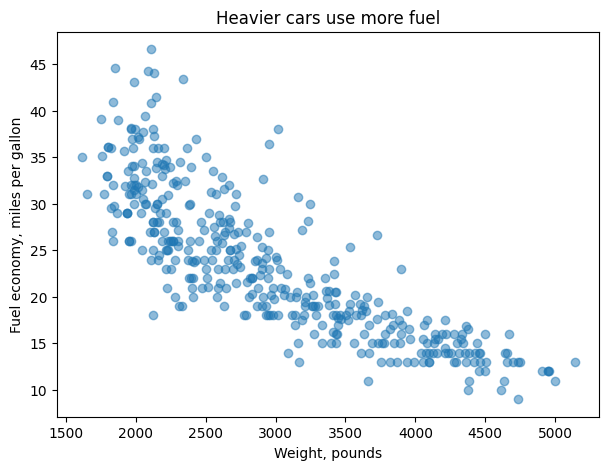

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(cars["weight"], cars["mpg"], alpha=0.5)

ax.set_xlabel("Weight, pounds")
ax.set_ylabel("Fuel economy, miles per gallon")
ax.set_title("Heavier cars use more fuel")

plt.show()

In [9]:
print("correlation:", round(cars["weight"].corr(cars["mpg"]), 3))

correlation: -0.832


**-0.83.** One of the strongest relationships you will meet in a real dataset, and it is not a
coincidence: moving more mass a mile takes more energy. The curve also bends — the penalty for the
first extra thousand pounds is bigger than for the second.

Color by origin, and a second story appears.

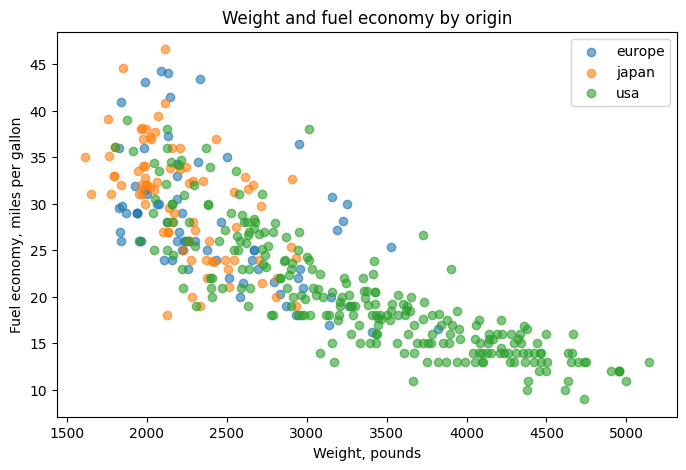

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for origin, group in cars.groupby("origin"):
    ax.scatter(group["weight"], group["mpg"], label=origin, alpha=0.6)

ax.set_xlabel("Weight, pounds")
ax.set_ylabel("Fuel economy, miles per gallon")
ax.set_title("Weight and fuel economy by origin")
ax.legend()

plt.show()

The three groups barely overlap. Japanese and European cars sit in the light, efficient corner;
American cars fill the heavy, thirsty half of the figure, with a few in the middle.

That reframes the bar chart in question 2. American cars did not get worse fuel economy *for their
weight* — they were heavier. Whether that is a fact about engineering or about what Americans bought
is not a question this table can answer.

## 4. One variable, spread out

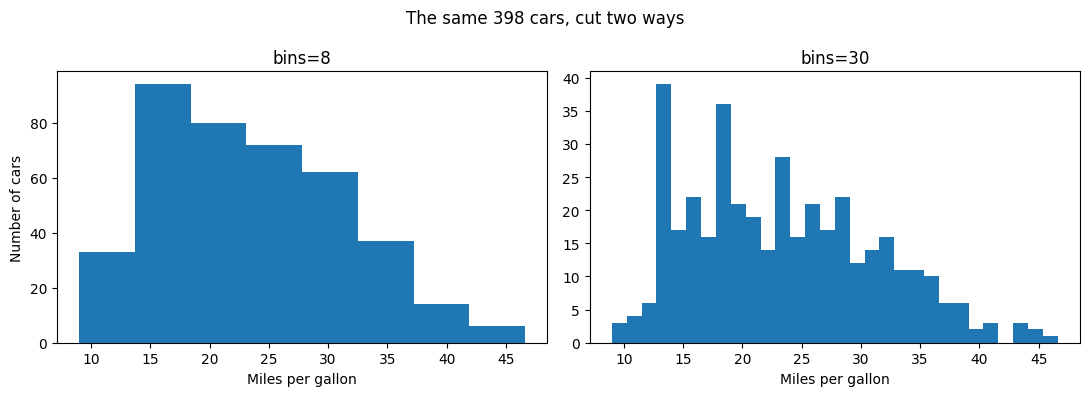

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4), sharey=False)

axes[0].hist(cars["mpg"], bins=8)
axes[0].set_title("bins=8")
axes[0].set_xlabel("Miles per gallon")
axes[0].set_ylabel("Number of cars")

axes[1].hist(cars["mpg"], bins=30)
axes[1].set_title("bins=30")
axes[1].set_xlabel("Miles per gallon")

fig.suptitle("The same 398 cars, cut two ways")
fig.tight_layout()

plt.show()

Eight bins says "one hump, slightly right-skewed". Thirty says the same thing with more noise and a
visible thinning around 30 mpg. Neither is wrong; eight is easier to read and thirty is harder to
mislead with, and this is why you always try more than one.

Somewhere between the two is usually right. Here 20 is a reasonable choice.

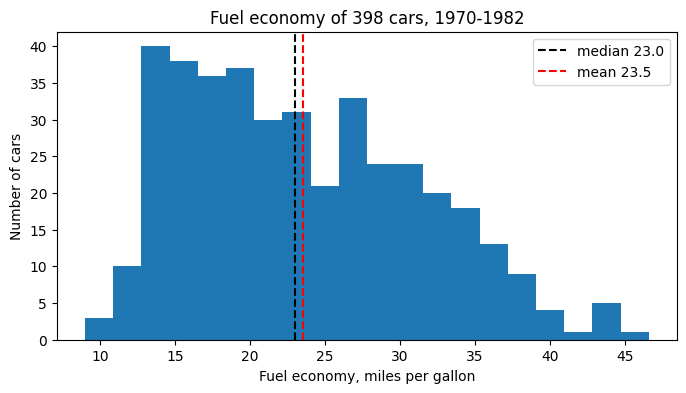

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cars["mpg"], bins=20)

ax.axvline(cars["mpg"].median(), color="black", linestyle="--",
           label=f"median {cars['mpg'].median():.1f}")
ax.axvline(cars["mpg"].mean(), color="red", linestyle="--",
           label=f"mean {cars['mpg'].mean():.1f}")

ax.set_xlabel("Fuel economy, miles per gallon")
ax.set_ylabel("Number of cars")
ax.set_title("Fuel economy of 398 cars, 1970-1982")
ax.legend()

plt.show()

Median 23.0, mean 23.5 — half a mile per gallon apart, which is what a roughly symmetric distribution
looks like. Compare that with the emissions-per-person histogram from the lecture, where the mean was
80% above the median. When those two numbers are close, an average is a fair summary; when they are
far apart, it is not.

## 5. Two quantities, two scales

Weight is in thousands of pounds and fuel economy is in tens of miles per gallon. Put them on the same
y-axis and one of them is a flat line along the bottom. `ax.twinx()` makes a second `Axes` that shares
the x-axis and has its own y-axis on the right.

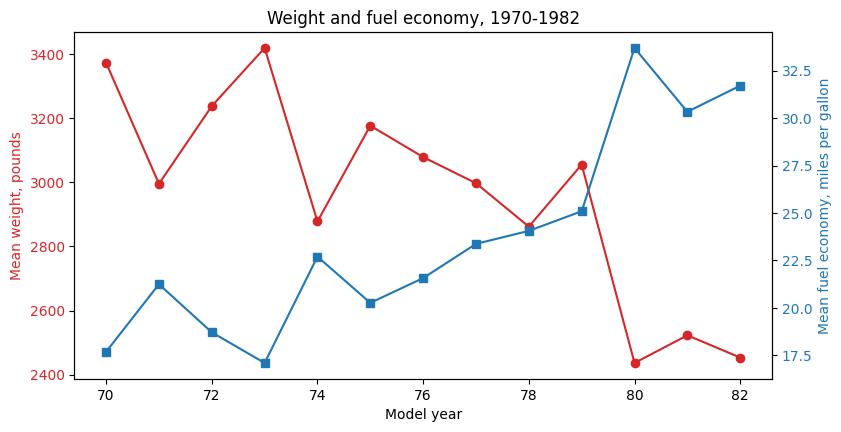

In [13]:
annual = cars.groupby("model_year").agg(
    mean_mpg=("mpg", "mean"),
    mean_weight=("weight", "mean"),
)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(annual.index, annual["mean_weight"], color="tab:red", marker="o")
ax.set_xlabel("Model year")
ax.set_ylabel("Mean weight, pounds", color="tab:red")
ax.tick_params(axis="y", labelcolor="tab:red")

right = ax.twinx()

right.plot(annual.index, annual["mean_mpg"], color="tab:blue", marker="s")
right.set_ylabel("Mean fuel economy, miles per gallon", color="tab:blue")
right.tick_params(axis="y", labelcolor="tab:blue")

ax.set_title("Weight and fuel economy, 1970-1982")

plt.show()

In [14]:
print("mean weight 1970 -> 1982:", round(annual.loc[70, "mean_weight"]), "->",
      round(annual.loc[82, "mean_weight"]),
      f"({(annual.loc[82, 'mean_weight'] / annual.loc[70, 'mean_weight'] - 1) * 100:.0f}%)")
print("mean mpg    1970 -> 1982:", round(annual.loc[70, "mean_mpg"], 1), "->",
      round(annual.loc[82, "mean_mpg"], 1),
      f"(+{(annual.loc[82, 'mean_mpg'] / annual.loc[70, 'mean_mpg'] - 1) * 100:.0f}%)")
print()
print("correlation of the two annual means:", round(annual["mean_mpg"].corr(annual["mean_weight"]), 3))

mean weight 1970 -> 1982: 3373 -> 2454 (-27%)
mean mpg    1970 -> 1982: 17.7 -> 31.7 (+79%)

correlation of the two annual means: -0.966


The average car lost **27% of its weight** and gained **79% in fuel economy**, and the two lines are
close to mirror images.

**There is no legend, and there does not need to be one.** Each axis label is drawn in the color of its
own line, and `tick_params(labelcolor=...)` carries the color onto the numbers. That is the standard
fix for a twin-axis chart: without something tying each line to its axis, the reader has to guess, and
half of them will guess wrong.

> ⚠️ **Warning:** A twin-axis chart has two free scales, so it can make almost any pair of series look
related - stretch one axis and the lines meet. The correlation between these two annual means is
**-0.97**, which sounds conclusive and is worth almost nothing on its own: there are thirteen points,
both series trend steadily through time, and any two quantities that both trend will correlate. The
scatter in question 3, with one point per car and no time in it at all, is the honest version of the
same claim.

## 6. What is each figure saying?

| Figure | The sentence |
|---|---|
| Line, by year | Fuel economy roughly doubled between 1970 and 1982, and most of that happened after 1978. |
| Line, by year and origin | Every origin improved, and the American fleet started far behind — but only the American line has enough cars behind it to trust. |
| Bar, by origin | Across this whole sample, Japanese cars average 10 mpg more than American ones. |
| Scatter, weight against mpg | Almost all of the difference in fuel economy is a difference in weight. |
| Twin axes, weight and mpg by year | The fleet got lighter and more efficient together, and by about the same time. |
| Histogram | Fuel economy is roughly symmetric around 23 mpg, so the average is a fair summary of it. |

**The two I would drop, in order:** the plain line by year, because the split version contains it; and
then the bar chart, because the scatter explains what the bar chart merely reports. Six figures for six
sentences is far too many; a report would carry two of these - almost certainly the scatter and the
twin-axis chart, because between them they say *what changed* and *why*.

### Things worth noticing

- **Reshaping is not optional in the multi-line chart.** `groupby` on two columns gives a long table,
  and one line per origin needs either a loop over groups or a `pivot`. This is the shape decision from
  the lecture arriving in the first exercise that needed it.
- **`sharey` was set to `False` on purpose** in the two-histogram figure, because the two panels count
  cars into different-sized bins and their y-axes genuinely are not comparable. That is the one case
  where independent axes are right — and it is worth stating rather than leaving to chance.
- **A trend line and a small sample look identical.** The only thing that separated them here was
  counting, and the count came from the same `groupby` that produced the means.

### What this notebook does NOT do

- **It never addresses the six missing horsepower values.** They do not touch any chart drawn here, and
  the moment you draw horsepower against anything, you are drawing 392 cars and calling them 398.
- **The scatter plots have no line through them.** The eye is fitting one, and "the relationship bends"
  is a claim made by looking. Putting a number on that is next week's job.
- **`origin` is treated as a fact about the car.** It is the manufacturer's home country, not where the
  car was built or sold, and by 1982 that distinction had already started to blur.